First Pipeline to run binding energy


In [6]:
!uv pip install fairchem-core

Using Python 3.13.11 environment at: /Users/christopherli/miniconda3/envs/cms
Audited 1 package in 62ms


In [1]:
# check through Hugging Face Hub if the package is installed correctly, paste result in chatgpt or claude to confirm
# you mainly need to check off " Read access to contents of all public gated repos you can access" and " Read access to contents of all private gated repos you can access" in tokens settings in Hugging Face Hub, and that the token is correctly set up in your environment variables
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '69d68ea13c3376473bce2de0', 'name': 'cl6767', 'fullname': 'Christopher Li', 'isPro': False, 'avatarUrl': '/avatars/e3e198b7951f0d1e6e6f0a47dc0e1f79.svg', 'orgs': [{'type': 'org', 'id': '64374111a701a7e744c02b0e', 'name': 'princetonu', 'fullname': 'Princeton University', 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/68e396f2b5bb631e9b2fac9a/b3xXusq8Zz3ej8Z6fRTSZ.png'}], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'UMA', 'role': 'fineGrained', 'createdAt': '2026-04-08T18:31:19.183Z', 'fineGrained': {'canReadGatedRepos': False, 'global': [], 'scoped': [{'entity': {'_id': '67098f31ee3ea12411d3f44e', 'type': 'model', 'name': 'facebook/OMAT24'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '67f5b60a8f60757d94e3c170', 'type': 'model', 'name': 'facebook/OMol25'}, 'permissions': ['repo.content.read']}, {'entity': {'_id': '67f5bb06b8e3712b3da49bfc', 'type': 'model', 'name': 'facebook/UMA'}, 'permissions': ['repo.con

In [2]:
from fairchem.core import pretrained_mlip

predictor = pretrained_mlip.get_predict_unit(
    model_name="uma-s-1p1",
    device="cpu"
)

W0416 20:29:03.234000 54433 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Warp DeprecationWarning: The symbol `warp.vec` will soon be removed from the public API. Use `warp.types.vector` instead.


In [3]:
# test with calculator 
from ase.build import bulk
from fairchem.core import pretrained_mlip, FAIRChemCalculator

device = "cpu"

atoms = bulk("Si")

model_name = "uma-s-1p1"
predictor = pretrained_mlip.get_predict_unit(model_name)
calc = FAIRChemCalculator(predictor, task_name="omat")

atoms.calc = calc
e = atoms.get_potential_energy()
print(e)



-10.823116832438327


In [4]:
from ase.io import read
from ase.build import molecule
from ase.optimize import BFGS

# -------------------------
# Load structures
# -------------------------
mof_74 = read("mg_mof74.cif")
co2 = molecule("CO2")

# -------------------------
# Assign calculator
# -------------------------
mof_74.calc = calc
co2.calc = calc

# -------------------------
# Relax MOF
# -------------------------
opt_mof = BFGS(mof_74, logfile="opt_mof_74.log")
opt_mof.run(fmax=0.01)

E_mof = mof_74.get_potential_energy()
print(f"E(Mg-MOF-74) = {E_mof:.6f} eV")

# Relax CO2
co2.center(vacuum=10.0)  # IMPORTANT (no periodic interactions)

opt_co2 = BFGS(co2, logfile="opt_co2.log")
opt_co2.run(fmax=0.01)

E_co2 = co2.get_potential_energy()
print(f"E(CO2, free) = {E_co2:.6f} eV")

E(Mg-MOF-74) = -1177.415309 eV
E(CO2, free) = -22.596883 eV


In [5]:
import numpy as np
# get indices of metal atoms (Mg)
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]
metal_positions = mof_74.positions[metal_indices]

In [6]:
# center of unit cell (cartesian)
cell_center = np.dot([0.5, 0.5, 0.5], mof_74.get_cell())

def get_direction(metal_pos):
    direction = cell_center - metal_pos
    return direction / np.linalg.norm(direction)

In [7]:
from ase.geometry import get_distances
import numpy as np

def is_valid_position_full(mof, co2, cutoff=1.6):
    dmat = get_distances(
        mof.positions,
        co2.positions,
        cell=mof.get_cell(),
        pbc=mof.get_pbc()
    )[1]
    return np.min(dmat) > cutoff

In [8]:
def get_directions():
    dirs = [
        [1,0,0], [-1,0,0],
        [0,1,0], [0,-1,0],
        [0,0,1], [0,0,-1]
    ]
    return [np.array(d)/np.linalg.norm(d) for d in dirs]

In [9]:
def place_co2_oriented(mof, co2, metal_index):
    metal_pos = mof.positions[metal_index]

    directions = get_directions()

    for direction in directions:

        for d_mg_o in np.linspace(2.2, 2.8, 7):

            co2_copy = co2.copy()

            # align CO2 axis
            co2_axis = co2_copy.positions[2] - co2_copy.positions[0]
            co2_axis /= np.linalg.norm(co2_axis)

            v = np.cross(co2_axis, direction)
            angle = np.degrees(np.arccos(np.clip(np.dot(co2_axis, direction), -1, 1)))

            if np.linalg.norm(v) > 1e-8:
                co2_copy.rotate(angle, v, center='COM')

            # place oxygen
            target = metal_pos + d_mg_o * direction
            shift = target - co2_copy.positions[0]
            co2_copy.positions += shift

            if is_valid_position_full(mof, co2_copy):

                metadata = {
                    "metal_index": metal_index,
                    "direction": direction,
                    "mg_o_distance": d_mg_o
                }

                return co2_copy, metadata

    return None, None

In [10]:
# combine system + computing binding energy 
def compute_binding_energy(mof, co2_placed):
    system = mof.copy()
    system += co2_placed

    system.calc = calc

    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    E_total = system.get_potential_energy()

    return E_total - E_mof - E_co2

In [11]:
# testing only for one magnesium site first (we can loop over all sites later)
mg_idx = 14
print(f"Testing Mg site index: {mg_idx}, symbol = {mof_74[mg_idx].symbol}")

if mof_74[mg_idx].symbol != "Mg":
    raise ValueError(f"Atom index {mg_idx} is not Mg. It is {mof_74[mg_idx].symbol}.")

co2_placed, metadata = place_co2_oriented(mof_74, co2, mg_idx)  # unpack tuple

if co2_placed is None:
    raise RuntimeError("Could not place CO2 near Mg without overlap.")

print("CO2 placed successfully")


Testing Mg site index: 14, symbol = Mg
CO2 placed successfully


In [18]:
from ase.io import read, write

# intialize combined system for inspection before relaxation
system = mof_74.copy()
system += co2_placed
system.calc = calc

# inspect Mg-O distances before relaxation
print("Initial Mg–O distances:")
for j in range(len(mof_74), len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(d)


# -------------------------
# Relax combined system
# -------------------------
opt_system = BFGS(system, logfile="opt_single_site.log")
opt_system.run(fmax=0.05)

E_total = system.get_potential_energy()
E_bind = E_total - E_mof - E_co2

print(f"E(total)   = {E_total:.6f} eV")
print(f"E(bind)    = {E_bind:.6f} eV")

# -------------------------
# Inspect Mg-O distances after relaxation
# -------------------------
co2_start = len(mof_74)
for j in range(co2_start, len(system)):
    if system[j].symbol == "O":
        d = system.get_distance(mg_idx, j, mic=True)
        print(f"Mg-O distance to O atom {j}: {d:.3f} Å")



Initial Mg–O distances:
1.6197117405824133
3.9802787763384937
E(total)   = -1200.529892 eV
E(bind)    = -0.517698 eV
Mg-O distance to O atom 163: 2.367 Å
Mg-O distance to O atom 164: 4.390 Å


In [19]:
from ase.visualize import view

view(system)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>

In [20]:
# time to iterate across 3-4 sites 
metal_indices = [i for i, a in enumerate(mof_74) if a.symbol == "Mg"]

# pick first 4 for now
# 
test_sites = metal_indices # [:4]

print(f"Testing {len(test_sites)} Mg sites:", test_sites)

Testing 18 Mg sites: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [ ]:
from ase.visualize import view

for idx in test_sites:
    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    system = mof_74.copy()
    system += co2_placed

    print(f"Viewing site {idx}")
    print("Direction:", meta["direction"])
    print("Mg-O distance:", meta["mg_o_distance"])

    view(system)
    input("Press Enter to continue...") # remember to do this lol

Viewing site 0
Direction: [-1.  0.  0.]
Mg-O distance: 2.8


In [ ]:
results = []

for idx in test_sites:

    co2_placed, meta = place_co2_oriented(mof_74, co2, idx)

    if co2_placed is None:
        print(f"Site {idx}: placement failed")
        continue

    print(f"\nSite {idx}")
    print("Start Mg-O distance:", meta["mg_o_distance"])
    print("Direction:", meta["direction"])

    # build system
    system = mof_74.copy()
    system += co2_placed
    system.calc = calc

    co2_start = len(mof_74)
    start_dist = system.get_distance(idx, co2_start, mic=True)

    # relax
    opt = BFGS(system, logfile=None)
    opt.run(fmax=0.05)

    # find closest O in CO2 to Mg after relaxation (CO2 may have flipped)
    o_distances = {}
    for j in range(co2_start, len(system)):
        if system[j].symbol == "O":
            d = system.get_distance(idx, j, mic=True)
            o_distances[j] = d
            print(f"  O atom {j}: Mg-O = {d:.3f} Å")

    closest_o_idx = min(o_distances, key=o_distances.get)
    final_mg_o_dist = o_distances[closest_o_idx]

    # energies
    E_total = system.get_potential_energy()
    E_bind = E_total - E_mof - E_co2

    print(f"Final Mg-O distance (closest O, atom {closest_o_idx}): {final_mg_o_dist:.3f} Å")
    print("E_bind:", E_bind)

    results.append({
        "site": idx,
        "E_bind": E_bind,
        "direction": meta["direction"],
        "distance": meta["mg_o_distance"],
        "start_dist": start_dist,
        "final_mg_o_dist": final_mg_o_dist,
    })


Site 0
Start Mg-O distance: 2.8
Direction: [-1.  0.  0.]
  O atom 163: Mg-O = 2.346 Å
  O atom 164: Mg-O = 4.389 Å
Final Mg-O distance (closest O, atom 163): 2.346 Å
E_bind: -0.5518497228622365

Site 1
Start Mg-O distance: 2.8
Direction: [ 0. -1.  0.]
  O atom 163: Mg-O = 2.341 Å
  O atom 164: Mg-O = 4.189 Å
Final Mg-O distance (closest O, atom 163): 2.341 Å
E_bind: -0.566299796104424

Site 2
Start Mg-O distance: 2.8
Direction: [0. 1. 0.]
  O atom 163: Mg-O = 2.369 Å
  O atom 164: Mg-O = 4.411 Å
Final Mg-O distance (closest O, atom 163): 2.369 Å
E_bind: -0.522873282432549

Site 3
Start Mg-O distance: 2.8
Direction: [1. 0. 0.]
  O atom 163: Mg-O = 2.340 Å
  O atom 164: Mg-O = 4.384 Å
Final Mg-O distance (closest O, atom 163): 2.340 Å
E_bind: -0.562027335166924

Site 4
Start Mg-O distance: 2.8
Direction: [0. 1. 0.]
  O atom 163: Mg-O = 2.340 Å
  O atom 164: Mg-O = 4.205 Å
Final Mg-O distance (closest O, atom 163): 2.340 Å
E_bind: -0.570541739463799

Site 5
Start Mg-O distance: 2.8
Direc

In [ ]:
# view results arra
for r in results:
    print(f"Site {r['site']}: E_bind = {r['E_bind']:.3f} eV, direction = {r['direction']}, distance = {r['final_mg_o_dist']:.2f} Å")

# break them into their own arrays for plotting
sites = [r["site"] for r in results]        
E_bind = [r["E_bind"] for r in results]
dist = [r["final_mg_o_dist"] for r in results]


Site 0: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 1: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance = 2.34 Å
Site 2: E_bind = -0.523 eV, direction = [0. 1. 0.], distance = 2.37 Å
Site 3: E_bind = -0.562 eV, direction = [1. 0. 0.], distance = 2.34 Å
Site 4: E_bind = -0.571 eV, direction = [0. 1. 0.], distance = 2.34 Å
Site 5: E_bind = -0.528 eV, direction = [ 0. -1.  0.], distance = 2.36 Å
Site 6: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 7: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance = 2.34 Å
Site 8: E_bind = -0.523 eV, direction = [0. 1. 0.], distance = 2.37 Å
Site 9: E_bind = -0.562 eV, direction = [1. 0. 0.], distance = 2.34 Å
Site 10: E_bind = -0.571 eV, direction = [0. 1. 0.], distance = 2.34 Å
Site 11: E_bind = -0.528 eV, direction = [ 0. -1.  0.], distance = 2.36 Å
Site 12: E_bind = -0.552 eV, direction = [-1.  0.  0.], distance = 2.35 Å
Site 13: E_bind = -0.566 eV, direction = [ 0. -1.  0.], distance =

In [ ]:
# take the 3 most low binding sites and print out their details
sorted_results = sorted(results, key=lambda x: x["E_bind"])
for r in sorted_results[:3]:
    print(f"Site {r['site']}: E_bind = {r['E_bind']:.3f} eV, direction = {r['direction']}, distance = {r['final_mg_o_dist']:.2f} Å")


Site 4: E_bind = -0.571 eV, direction = [0.0, 1.0, 0.0], distance = 2.34 Å
Site 10: E_bind = -0.571 eV, direction = [0.0, 1.0, 0.0], distance = 2.34 Å
Site 16: E_bind = -0.571 eV, direction = [0.0, 1.0, 0.0], distance = 2.34 Å


TypeError: 'float' object is not iterable

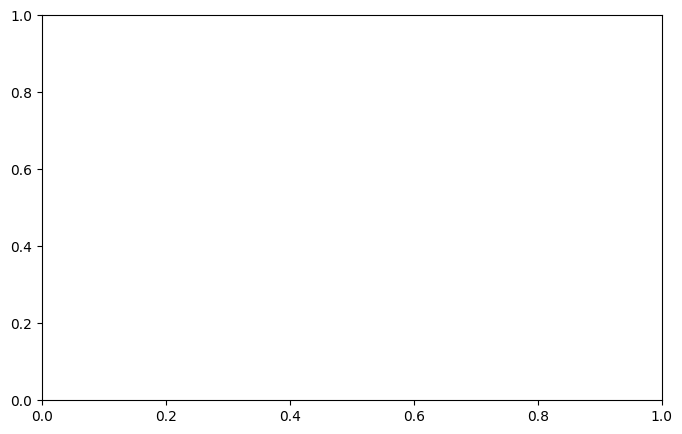

In [ ]:
import matplotlib.pyplot as plt
from datetime import datetime

# binding energy plot vs. site index
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, e) in enumerate(zip(test_sites, E_bind)):
    ax.scatter(site_idx, e, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Atom {site_idx}", s=80)
    ax.annotate(
        f"{e:.2f}",
        xy=(site_idx, e),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel("Mg Site (atom index)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title("Binding Energy Across Mg Sites")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_across_sites_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

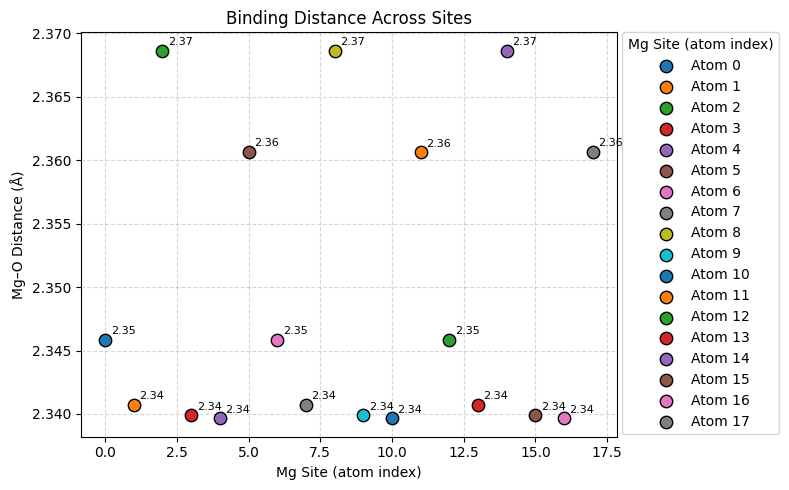

In [ ]:
# Binding distance across sites
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, d) in enumerate(zip(test_sites, dist)):
    ax.scatter(site_idx, d, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Atom {site_idx}", s=80)
    ax.annotate(
        f"{d:.2f}",
        xy=(site_idx, d),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlabel("Mg Site (atom index)")
ax.set_ylabel("Mg–O Distance (Å)")
ax.set_title("Binding Distance Across Sites")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_distance_across_sites_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

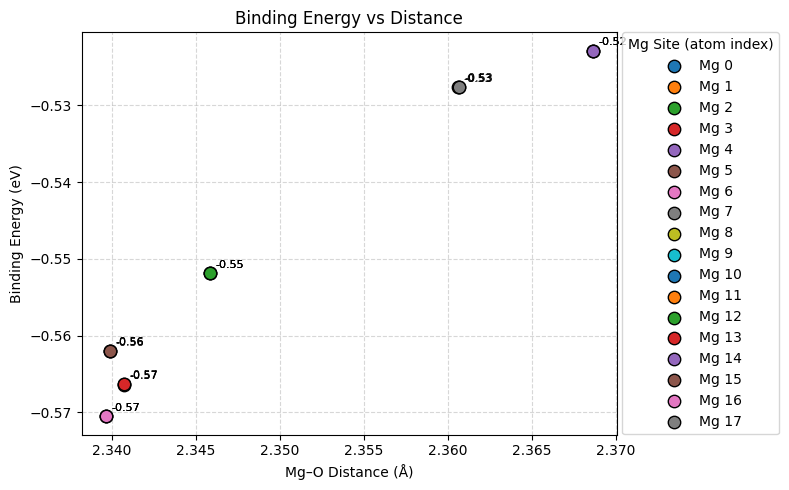

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, d, e) in enumerate(zip(test_sites, dist, E_bind)):
    ax.scatter(d, e, color=colors[i % 10], edgecolors='black',
               zorder=3, label=f"Mg {site_idx}", s=80)
    ax.annotate(
        f"{e:.2f}",
        xy=(d, e),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_xlabel("Mg–O Distance (Å)")
ax.set_ylabel("Binding Energy (eV)")
ax.set_title("Binding Energy vs Distance")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_vs_distance_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

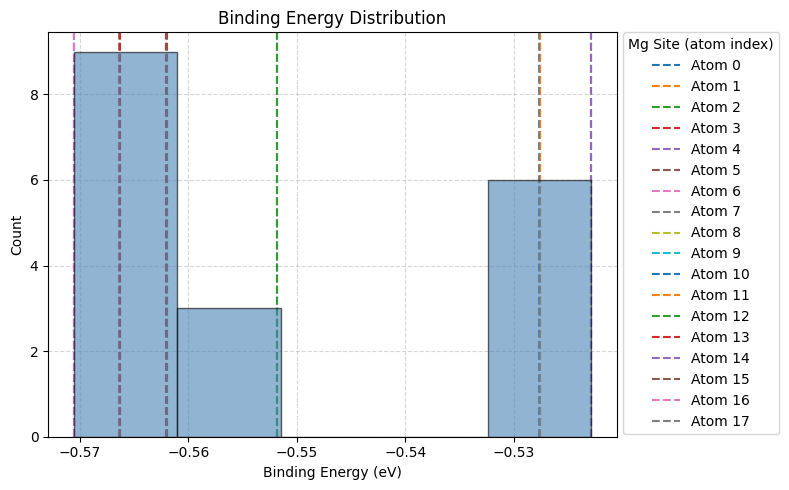

In [ ]:
# binding energy distribution 
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10.colors

for i, (site_idx, e) in enumerate(zip(test_sites, E_bind)):
    ax.axvline(e, color=colors[i % 10], linestyle='--', linewidth=1.5, label=f"Atom {site_idx}")

ax.hist(E_bind, bins=5, color='steelblue', edgecolor='black', alpha=0.6, zorder=2)

ax.set_xlabel("Binding Energy (eV)")
ax.set_ylabel("Count")
ax.set_title("Binding Energy Distribution")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Mg Site (atom index)", bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"binding_energy_distribution_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import json
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"results_{timestamp}.txt"

for r in results:
    r["direction"] = r["direction"].tolist()

with open(filename, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved to {filename}")

Saved to results_20260410_143837.txt


# This is where the MD stuff starts

**Test**

In [ ]:
# build system

system = mof_74.copy()
system += co2_placed
system.calc = calc

In [17]:
# initialize velocities

from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.velocitydistribution import Stationary


#MaxwellBoltzmannDistribution(system, temperature_K=300)
#Stationary(system)

In [ ]:
# run MD using nose-hoover chain
# acknowledge that n=1000 is short time

from ase.md.npt import NPT
from ase.units import fs
from ase.md.nose_hoover_chain import NoseHooverChainNVT

dyn = NoseHooverChainNVT(
    system,
    timestep=1.0 * fs,
    temperature_K=300,
    tdamp=100 * fs,
    trajectory="md.traj",
    logfile="md.log"
)
print("MD start")
dyn.run(steps=1000)
print("MD finish")

MD start
MD finish


In [ ]:
# recording binding distance

from ase.io import Trajectory
import numpy as np

traj = Trajectory("md.traj")

distances = []

for atoms in traj:
    mof_len = len(mof_74)

    # CO2 oxygen atoms assumed last 2 atoms
    o_indices = [mof_len, mof_len + 1]

    mg_pos = atoms[mg_idx].position

    d = min(
        np.linalg.norm(atoms[i].position - mg_pos)
        for i in o_indices
    )

    distances.append(d)



In [ ]:
trajectory = read("md.traj", index=":")
view(trajectory)

<Popen: returncode: None args: ['/Users/christopherli/miniconda3/envs/cms/bi...>

**MD for range of temperatures**

In [12]:
# ============================================================
# MD Simulation — Mg atom index 4 (lowest binding energy site)
# ============================================================

import numpy as np
from ase import units
from ase.md.langevin import Langevin
from ase.io import write
from ase.io.trajectory import Trajectory
from datetime import datetime
import time

# -------------------------------------------------------
# 1. Target site: atom index 4 from the binding energy plot
# -------------------------------------------------------

best_mg_idx  = 4
static_E_bind = -0.57
print(f"Mg site index : {best_mg_idx}")
print(f"E_bind        : {static_E_bind:.4f} eV")

Mg site index : 4
E_bind        : -0.5700 eV


In [13]:
# -------------------------------------------------------
# 2. Build and pre-relax the starting structure
#    (re-place CO2 near the target site)
# -------------------------------------------------------

# re-initialize calculator
from fairchem.core import pretrained_mlip, FAIRChemCalculator

predictor = pretrained_mlip.get_predict_unit("uma-s-1p1")
calc = FAIRChemCalculator(predictor, task_name="omat")

co2_placed, meta = place_co2_oriented(mof_74, co2, best_mg_idx)
if co2_placed is None:
    raise RuntimeError(f"Could not place CO2 at site {best_mg_idx}.")

system_md = mof_74.copy()
system_md += co2_placed
system_md.calc = calc

print("Pre-relaxing structure before MD...")
t0 = time.time()
opt = BFGS(system_md, logfile="md_prerelax.log")
opt.run(fmax=0.05)
print(f"Pre-relaxation done in {time.time()-t0:.1f}s")
print(f"E_bind (pre-MD) = {system_md.get_potential_energy() - E_mof - E_co2:.4f} eV")

Pre-relaxing structure before MD...
Pre-relaxation done in 107.5s
E_bind (pre-MD) = -0.5705 eV


In [14]:
# -------------------------------------------------------
# 3. MD helper: run one temperature in ~minutes not hours
# -------------------------------------------------------
def run_md(system_in, temperature_K, n_steps=1000, timestep_fs=1.0,
           tdamp_fs=100, traj_every=10, log_every=50):

    atoms = system_in.copy()
    atoms.calc = calc

    MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)
    Stationary(atoms)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    traj_file = f"md_site{best_mg_idx}_{temperature_K}K_{timestamp}.traj"
    log_file  = f"md_site{best_mg_idx}_{temperature_K}K_{timestamp}.log"

    dyn = NoseHooverChainNVT(
        atoms,
        timestep      = timestep_fs * fs,
        temperature_K = temperature_K,
        tdamp         = tdamp_fs * fs,
        trajectory    = traj_file,
        logfile       = log_file,
    )

    records = []

    def log_step():
        step  = dyn.get_number_of_steps()
        E_pot = atoms.get_potential_energy()
        E_b   = E_pot - E_mof - E_co2
        records.append((step, E_pot, E_b))
        if step % log_every == 0:
            print(f"  step {step:4d} | T = {atoms.get_temperature():6.1f} K | "
                  f"E_pot = {E_pot:.4f} eV | E_bind = {E_b:.4f} eV")

    dyn.attach(log_step, interval=traj_every)

    print(f"\n{'='*55}")
    print(f"  MD  |  T = {temperature_K} K  |  {n_steps} steps  |  {len(atoms)} atoms")
    print(f"{'='*55}")

    t_start = time.time()
    dyn.run(steps=n_steps)
    elapsed = time.time() - t_start

    print(f"\n  Done in {elapsed:.1f}s  ({elapsed/n_steps*1000:.0f} ms/step)")
    print(f"  Trajectory saved → {traj_file}")

    return atoms, records, traj_file

In [19]:
# -------------------------------------------------------
# 4. Run at 300 K
# -------------------------------------------------------
# 500 steps × ~1–3 s/step ≈ 8–25 min on CPU.
# Reduce n_steps to 200 for a quick sanity check first.
from ase.md.npt import NPT
from ase.units import fs
from ase.md.nose_hoover_chain import NoseHooverChainNVT

final_300, records_300, traj_300 = run_md(system_md, temperature_K=300)


  MD  |  T = 300 K  |  1000 steps  |  165 atoms
  step    0 | T =  315.9 K | E_pot = -1200.5827 eV | E_bind = -0.5705 eV
  step   50 | T =  148.5 K | E_pot = -1196.6631 eV | E_bind = 3.3491 eV
  step  100 | T =  174.5 K | E_pot = -1196.7001 eV | E_bind = 3.3121 eV
  step  150 | T =  209.7 K | E_pot = -1196.8071 eV | E_bind = 3.2051 eV
  step  200 | T =  205.0 K | E_pot = -1195.9666 eV | E_bind = 4.0456 eV
  step  250 | T =  230.2 K | E_pot = -1195.6849 eV | E_bind = 4.3273 eV
  step  300 | T =  280.5 K | E_pot = -1195.9436 eV | E_bind = 4.0686 eV
  step  350 | T =  249.2 K | E_pot = -1194.4214 eV | E_bind = 5.5908 eV
  step  400 | T =  274.8 K | E_pot = -1194.1490 eV | E_bind = 5.8632 eV
  step  450 | T =  298.2 K | E_pot = -1193.9803 eV | E_bind = 6.0319 eV
  step  500 | T =  265.4 K | E_pot = -1192.7303 eV | E_bind = 7.2819 eV
  step  550 | T =  319.0 K | E_pot = -1193.4577 eV | E_bind = 6.5545 eV
  step  600 | T =  345.2 K | E_pot = -1193.8216 eV | E_bind = 6.1906 eV
  step  650 | 

In [20]:
# -------------------------------------------------------
# 5. Run at 350 K  (start from 300 K final structure
#    so it's already equilibrated — saves steps)
# -------------------------------------------------------
final_350, records_350, traj_350 = run_md(final_300, temperature_K=350)


  MD  |  T = 350 K  |  1000 steps  |  165 atoms
  step    0 | T =  386.9 K | E_pot = -1194.4841 eV | E_bind = 5.5281 eV
  step   50 | T =  340.7 K | E_pot = -1193.4381 eV | E_bind = 6.5741 eV
  step  100 | T =  326.0 K | E_pot = -1192.8316 eV | E_bind = 7.1806 eV
  step  150 | T =  375.3 K | E_pot = -1193.2979 eV | E_bind = 6.7143 eV
  step  200 | T =  358.5 K | E_pot = -1192.4104 eV | E_bind = 7.6018 eV
  step  250 | T =  378.6 K | E_pot = -1192.6964 eV | E_bind = 7.3158 eV
  step  300 | T =  385.1 K | E_pot = -1192.9059 eV | E_bind = 7.1063 eV
  step  350 | T =  402.8 K | E_pot = -1193.4480 eV | E_bind = 6.5642 eV
  step  400 | T =  328.7 K | E_pot = -1192.1196 eV | E_bind = 7.8926 eV
  step  450 | T =  373.0 K | E_pot = -1193.3459 eV | E_bind = 6.6663 eV
  step  500 | T =  335.6 K | E_pot = -1192.8208 eV | E_bind = 7.1914 eV
  step  550 | T =  323.6 K | E_pot = -1192.6728 eV | E_bind = 7.3394 eV
  step  600 | T =  336.3 K | E_pot = -1193.0031 eV | E_bind = 7.0091 eV
  step  650 | T

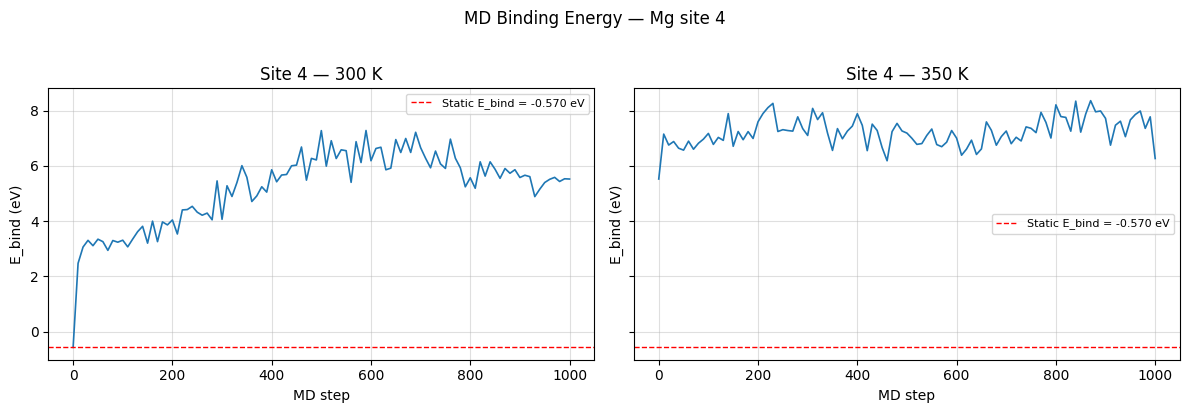

In [21]:
# -------------------------------------------------------
# 6. Plot: binding energy vs MD step for both temperatures
# -------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, records, T in zip(axes, [records_300, records_350], [300, 350]):
    steps  = [r[0] for r in records]
    E_bind = [r[2] for r in records]
    ax.plot(steps, E_bind, lw=1.2)
    ax.axhline(static_E_bind, color="red", ls="--", lw=1,
               label=f"Static E_bind = {static_E_bind:.3f} eV")
    ax.set_xlabel("MD step")
    ax.set_ylabel("E_bind (eV)")
    ax.set_title(f"Site {best_mg_idx} — {T} K")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle(f"MD Binding Energy — Mg site {best_mg_idx}", y=1.02)
plt.tight_layout()
plt.savefig(f"md_binding_energy_site{best_mg_idx}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# -------------------------------------------------------
# 7. Summary statistics
# -------------------------------------------------------
for records, T in [(records_300, 300), (records_350, 350)]:
    E_binds = np.array([r[2] for r in records])
    eq_cut  = len(E_binds) // 5
    prod    = E_binds[eq_cut:]
    print(f"\nT = {T} K  (production = {len(prod)} frames)")
    print(f"  <E_bind>  = {prod.mean():.4f} eV")
    print(f"  std       = {prod.std():.4f} eV")
    print(f"  min/max   = {prod.min():.4f} / {prod.max():.4f} eV")


T = 300 K  (production = 81 frames)
  <E_bind>  = 5.7287 eV
  std       = 0.8179 eV
  min/max   = 3.5367 / 7.2861 eV

T = 350 K  (production = 81 frames)
  <E_bind>  = 7.3196 eV
  std       = 0.4999 eV
  min/max   = 6.1893 / 8.3665 eV


In [23]:
# -------------------------------------------------------
# 5. Run temperatures from 400K to 1000K in 50K increments
#    each starting from the previous temperature's final structure
# -------------------------------------------------------

temperatures = range(400, 1050, 50)

all_records = {300: records_300, 350: records_350}
all_trajs   = {300: traj_300,    350: traj_350}
final_structs = {350: final_350}

current_structure = final_350

for T in temperatures:
    print(f"\nStarting MD at {T} K...")
    final_T, records_T, traj_T = run_md(current_structure, temperature_K=T)
    
    all_records[T] = records_T
    all_trajs[T]   = traj_T
    final_structs[T] = final_T
    
    current_structure = final_T  # warm start into next temperature

print("\nAll temperatures complete!")
print("Trajectories saved:")
for T, traj in all_trajs.items():
    print(f"  {T} K → {traj}")


Starting MD at 400 K...

  MD  |  T = 400 K  |  1000 steps  |  165 atoms
  step    0 | T =  435.5 K | E_pot = -1193.7409 eV | E_bind = 6.2713 eV
  step   50 | T =  344.9 K | E_pot = -1191.7243 eV | E_bind = 8.2878 eV
  step  100 | T =  366.5 K | E_pot = -1191.8524 eV | E_bind = 8.1598 eV
  step  150 | T =  414.7 K | E_pot = -1192.1037 eV | E_bind = 7.9085 eV
  step  200 | T =  376.0 K | E_pot = -1190.7927 eV | E_bind = 9.2195 eV
  step  250 | T =  425.1 K | E_pot = -1191.7306 eV | E_bind = 8.2815 eV
  step  300 | T =  416.6 K | E_pot = -1191.5156 eV | E_bind = 8.4966 eV
  step  350 | T =  364.2 K | E_pot = -1190.5240 eV | E_bind = 9.4882 eV
  step  400 | T =  427.2 K | E_pot = -1191.9754 eV | E_bind = 8.0368 eV
  step  450 | T =  410.9 K | E_pot = -1191.9600 eV | E_bind = 8.0522 eV
  step  500 | T =  382.5 K | E_pot = -1191.8903 eV | E_bind = 8.1219 eV
  step  550 | T =  375.3 K | E_pot = -1192.2883 eV | E_bind = 7.7239 eV
  step  600 | T =  360.1 K | E_pot = -1192.3615 eV | E_bind = 